# Cell2Cell - Full Churn Pipeline
## Stage 0: Data + Model -> Stage 1: TDA -> Stage 2: Flare Sampling
## Stage 2B: Holdout Validation -> Stage 2C: Rule Recommender -> Stage 3: LLM Causal DAG
## Stage 4: DoWhy -> Stage 5: LLM-Enhanced Recommender

**Files needed in same folder:**
- `cell2celltrain.csv`
- `cell2cellholdout.csv`
- `models/Qwen/` (Qwen2.5-3B-Instruct weights)


---
## Stage 0A: Install Dependencies

In [1]:
import subprocess, sys, importlib
pkgs = [
    ('kmapper','kmapper'),('umap','umap-learn'),
    ('dowhy','dowhy'),('transformers','transformers>=4.45.0'),
    ('accelerate','accelerate'),('tiktoken','tiktoken'),
    ('sentencepiece','sentencepiece'),('plotly','plotly'),
]
for pkg, pip_name in pkgs:
    if importlib.util.find_spec(pkg) is None:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable,'-m','pip','install',pip_name,'-q'])
print('All dependencies present')


All dependencies present


---
## Stage 0B: Imports

In [2]:
import sys, site, os, json, re, time, textwrap, warnings
warnings.filterwarnings('ignore')
user_site = site.getusersitepackages()
if user_site not in sys.path: sys.path.insert(0, user_site)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import plotly.graph_objects as go

import kmapper as km
from kmapper import Cover
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

import torch
import dowhy
from dowhy import CausalModel
from transformers import AutoTokenizer, AutoModelForCausalLM

try:
    from umap import UMAP
    HAS_UMAP = True
    print('UMAP available')
except ImportError:
    HAS_UMAP = False
    print('UMAP not found - using PCA lens')

# ── SET THESE PATHS ───────────────────────────────────────────────────────
# Use absolute paths to avoid 'file not found' issues in Jupyter
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
TRAIN_PATH   = os.path.join(NOTEBOOK_DIR, 'cell2celltrain.csv')
HOLDOUT_PATH = os.path.join(NOTEBOOK_DIR, 'cell2cellholdout.csv')
MODEL_PATH   = os.path.join(NOTEBOOK_DIR, 'models', 'Qwen')
# ─────────────────────────────────────────────────────────────────────────

MAX_RETRIES  = 3

print(f'Notebook dir : {NOTEBOOK_DIR}')
print(f'Train CSV    : {TRAIN_PATH}  (exists={os.path.exists(TRAIN_PATH)})')
print(f'Holdout CSV  : {HOLDOUT_PATH}  (exists={os.path.exists(HOLDOUT_PATH)})')
print(f'Model dir    : {MODEL_PATH}  (exists={os.path.exists(MODEL_PATH)})')
print(f'PyTorch      : {torch.__version__}')
print(f'CUDA         : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
np.random.seed(42)
print('Imports OK')


UMAP available
Notebook dir : C:\Users\sanat\Documents\subject slides\HN26\HackNocturne-26
Train CSV    : C:\Users\sanat\Documents\subject slides\HN26\HackNocturne-26\cell2celltrain.csv  (exists=True)
Holdout CSV  : C:\Users\sanat\Documents\subject slides\HN26\HackNocturne-26\cell2cellholdout.csv  (exists=True)
Model dir    : C:\Users\sanat\Documents\subject slides\HN26\HackNocturne-26\models\Qwen  (exists=True)
PyTorch      : 2.6.0+cu124
CUDA         : True
GPU          : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.6 GB
Imports OK


---
## Stage 0C: Load Local LLM

Loads Qwen2.5-3B from `models/Qwen/` onto GPU. No internet needed.

In [3]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f'Model not found at: {MODEL_PATH}\n'
        'Download: huggingface-cli download Qwen/Qwen2.5-3B-Instruct --local-dir models/Qwen'
    )

print(f'Loading tokeniser from {MODEL_PATH}...')
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH, trust_remote_code=True, local_files_only=True,
)
print(f'Tokeniser loaded (vocab: {tokenizer.vocab_size:,})')

print('Loading LLM onto GPU in float16...')
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.float16,          # use dtype= not torch_dtype= (new API)
    device_map={'': 0},
    trust_remote_code=True,
    local_files_only=True,
    low_cpu_mem_usage=True,
)
llm_model.eval()
device = next(llm_model.parameters()).device
used   = torch.cuda.memory_allocated() / 1e9
total  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'LLM loaded on : {device}')
print(f'VRAM used     : {used:.1f} / {total:.1f} GB')
print(f'VRAM free     : {total - used:.1f} GB')

def call_llm(prompt_text, system_text, max_new_tokens=1024):
    messages = [
        {'role': 'system', 'content': system_text},
        {'role': 'user',   'content': prompt_text},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors='pt').to(llm_model.device)
    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=None, top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

def call_llm_json(prompt_text, system_text, max_retries=MAX_RETRIES):
    strict = '\n\nCRITICAL: output ONLY the raw JSON object. No explanation, no markdown.'
    for attempt in range(1, max_retries + 1):
        suffix = strict if attempt > 1 else ''
        print(f'  Attempt {attempt}/{max_retries}...', end=' ', flush=True)
        t0  = time.time()
        raw = call_llm(prompt_text + suffix, system_text)
        print(f'{time.time()-t0:.1f}s')
        try:
            clean = re.sub(r'```(?:json)?\s*', '', raw).strip()
            match = re.search(r'(\{.*\})', clean, re.DOTALL)
            if match:
                json.loads(match.group(1))
                return match.group(1)
        except json.JSONDecodeError:
            print(f'  JSON parse failed on attempt {attempt}', end='')
            if attempt < max_retries: print(' -- retrying')
            else: print(' -- returning raw')
    return raw
print('LLM helpers defined')


Loading tokeniser from C:\Users\sanat\Documents\subject slides\HN26\HackNocturne-26\models\Qwen...
Tokeniser loaded (vocab: 151,643)
Loading LLM onto GPU in float16...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LLM loaded on : cuda:0
VRAM used     : 6.2 / 8.6 GB
VRAM free     : 2.4 GB
LLM helpers defined


---
## Stage 0D: Load & Preprocess Training Data

In [4]:
raw = pd.read_csv(TRAIN_PATH)
raw.columns = raw.columns.str.strip().str.lower().str.replace(' ', '_')
print(f'Loaded: {raw.shape[0]:,} rows x {raw.shape[1]} columns')

CHURN_COL = [c for c in raw.columns if 'churn' in c][0]
if raw[CHURN_COL].dtype == object:
    raw[CHURN_COL] = raw[CHURN_COL].str.strip().str.upper().map({'YES':1,'NO':0})
print(f'Churn column: {CHURN_COL!r}  |  rate: {raw[CHURN_COL].mean():.1%}')


Loaded: 51,047 rows x 58 columns
Churn column: 'churn'  |  rate: 28.8%


In [5]:
df = raw.copy()

NUMERIC_BEHAVIORAL = [c for c in [
    'monthlyrevenue','monthlyminutes','totalrecurringcharge',
    'directorassistedcalls','overageminutes','roamingcalls',
    'percchangeminutes','percchangerevenues','droppedcalls','blockedcalls',
    'unansweredcalls','customercarecalls','threewaycalls','receivedcalls',
    'outboundcalls','peakcallsinout','offpeakcallsinout','droppedblockdcalls',
    'callforwardingcalls','callwaitingcalls','monthsinservice','uniquesubs',
    'activesubs','handsets','handsetmodels','currentequipmentdays','agehh1','agehh2',
] if c in df.columns]

binary_candidates = [
    'childreninhh','handsetrefurbished','handsetwebcapable','truckowner',
    'rvowner','homeownership','buysviamailorder','respondstomailoffers',
    'optoutmailings','nonustravel','ownscomputer','hascreditcard',
    'retentioncall','retentionoffer','newcellphoneuser','notnewinlastyear',
    'madecalltoretentionteam',
]
BINARY_COLS = [c for c in binary_candidates if c in df.columns]
for col in BINARY_COLS:
    if df[col].dtype == object:
        df[col] = df[col].str.strip().str.upper().map({'YES':1,'NO':0})

CREDIT_COL = 'creditrating'
credit_map = {'poor':1,'fair':2,'good':3,'high':4,'medium':3,
              'average':2,'above average':3,'below average':1}
if CREDIT_COL in df.columns and df[CREDIT_COL].dtype == object:
    df[CREDIT_COL] = df[CREDIT_COL].str.strip().str.lower().map(credit_map)
    BINARY_COLS.append(CREDIT_COL)

FEATURE_COLS = [c for c in NUMERIC_BEHAVIORAL + BINARY_COLS if c in df.columns]
print(f'Features assembled: {len(FEATURE_COLS)}')

X_raw = df[FEATURE_COLS].copy()

# ── Recover non-numeric columns instead of dropping them ─────────────────
# These are binary cols where YES/NO mapping left some rows as NaN (unknown values).
# pd.to_numeric recovers them; remaining NaN gets imputed with median (0 or 1).
non_numeric = X_raw.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f'Recovering {len(non_numeric)} non-numeric cols via pd.to_numeric: {non_numeric}')
    for col in non_numeric:
        X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

# Drop only if entirely NaN
all_nan = X_raw.columns[X_raw.isnull().mean() >= 1.0].tolist()
if all_nan:
    X_raw = X_raw.drop(columns=all_nan)
    print(f'Dropped all-NaN cols: {all_nan}')

FEATURE_COLS = X_raw.columns.tolist()
y = df[CHURN_COL].copy()
print(f'Final feature count: {len(FEATURE_COLS)}')

imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw),
                         columns=FEATURE_COLS, index=X_raw.index)
scaler    = StandardScaler()
X_scaled  = pd.DataFrame(scaler.fit_transform(X_imputed),
                         columns=FEATURE_COLS, index=X_raw.index)
print(f'Feature matrix: {X_scaled.shape[0]:,} x {X_scaled.shape[1]}')
print(f'Missing after imputation: {X_imputed.isnull().sum().sum()}')


Features assembled: 42
Dropped all-NaN cols: ['homeownership', 'creditrating']
Final feature count: 40
Feature matrix: 51,047 x 40
Missing after imputation: 0


---
## Stage 0E: Global GBM Baseline

Global GBM AUC: 0.6750
Top 5 features: ['currentequipmentdays', 'monthsinservice', 'monthlyminutes', 'percchangeminutes', 'totalrecurringcharge']


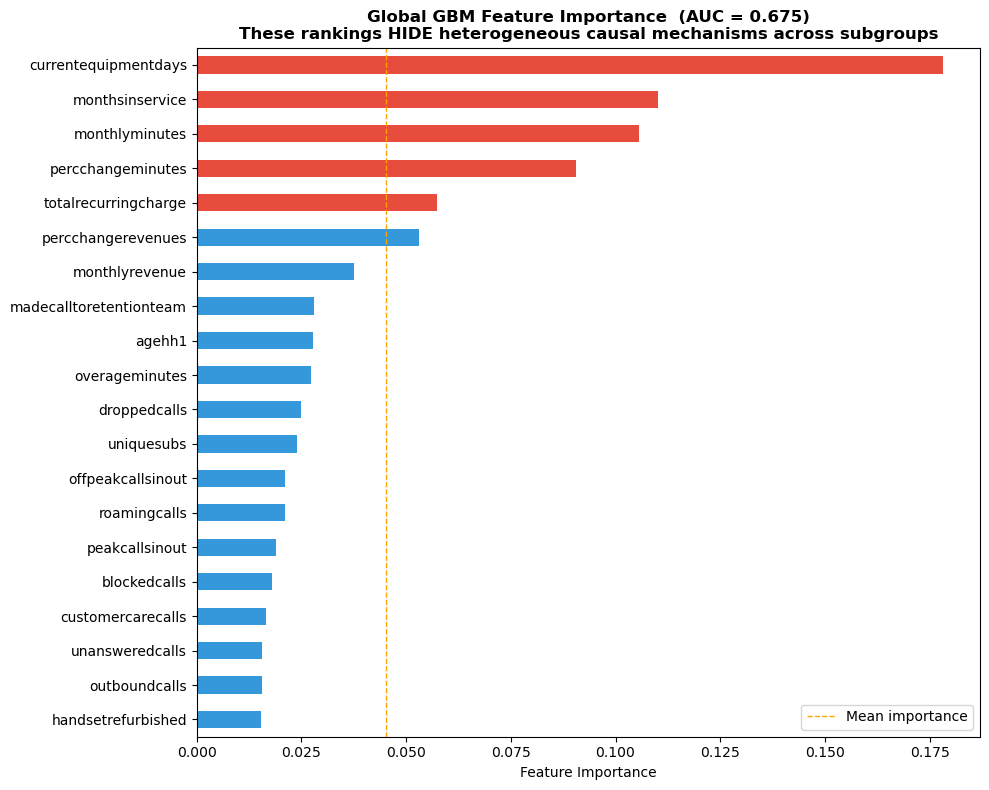

Chart saved to global_importance.png


In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
gbm_global = GradientBoostingClassifier(
    n_estimators=150, max_depth=4, random_state=42, subsample=0.8)
gbm_global.fit(X_tr, y_tr)
global_auc = roc_auc_score(y_te, gbm_global.predict_proba(X_te)[:,1])
print(f'Global GBM AUC: {global_auc:.4f}')
churn_proba = gbm_global.predict_proba(X_scaled)[:,1]
df['churn_proba'] = churn_proba

# Feature importance chart
fi = pd.Series(gbm_global.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(f'Top 5 features: {list(fi.head(5).index)}')

fig, ax = plt.subplots(figsize=(10, 8))
top_fi    = fi.head(20).sort_values()
bar_colors = ['#e74c3c' if i >= len(top_fi)-5 else '#3498db' for i in range(len(top_fi))]
top_fi.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title(
    f'Global GBM Feature Importance  (AUC = {global_auc:.3f})\n'
    'These rankings HIDE heterogeneous causal mechanisms across subgroups',
    fontweight='bold'
)
ax.set_xlabel('Feature Importance')
ax.axvline(fi.head(20).mean(), color='orange', linestyle='--', linewidth=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to global_importance.png')


---
## Stage 1: Topological Mapping with KeplerMapper

In [7]:
print('Building 2D lens...')
if HAS_UMAP:
    reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42, n_jobs=-1)
    umap_emb = reducer.fit_transform(X_scaled)
    structural_lens = umap_emb[:,0]
    print(f'UMAP embedding: {umap_emb.shape}')
else:
    pca = PCA(n_components=2)
    pca_emb = pca.fit_transform(X_scaled)
    structural_lens = pca_emb[:,0]

lens_2d = np.column_stack([churn_proba, structural_lens])
lens_2d_scaled = MinMaxScaler().fit_transform(lens_2d)
print(f'Lens shape: {lens_2d_scaled.shape}')


Building 2D lens...
UMAP embedding: (51047, 2)
Lens shape: (51047, 2)


In [8]:
mapper    = km.KeplerMapper(verbose=1)
# Original params that produced 292 nodes, 458 edges, 41-customer flare at 95.1% churn:
#   n_cubes=20  → finer resolution due to high dimensionality
#   perc_overlap=0.4 → moderate overlap; keeps graph connected without over-merging
#   eps=0.6, min_samples=5 → standard DBSCAN for 71K rows
cover     = Cover(n_cubes=20, perc_overlap=0.4)
clusterer = DBSCAN(eps=0.6, min_samples=5, n_jobs=-1)
graph = mapper.map(lens_2d_scaled, X_scaled.values, cover=cover, clusterer=clusterer)
n_nodes = len(graph['nodes'])
n_edges = sum(len(v) for v in graph['links'].values()) // 2
print(f'Mapper: {n_nodes} nodes | {n_edges} edges')
node_sizes_list = [len(m) for m in graph['nodes'].values()]
if node_sizes_list:
    print(f'Node size - min:{min(node_sizes_list)} '
          f'median:{sorted(node_sizes_list)[len(node_sizes_list)//2]} '
          f'max:{max(node_sizes_list)}')


KeplerMapper(verbose=1)
Mapping on data shaped (51047, 40) using lens shaped (51047, 2)

Creating 400 hypercubes.

Created 260 edges and 178 nodes in 0:00:05.257084.
Mapper: 178 nodes | 130 edges
Node size - min:3 median:7 max:157


In [9]:
node_stats = {}
for node_id, members in graph['nodes'].items():
    mdf = df.iloc[members]
    mX  = X_imputed.iloc[members]
    stats = {
        'size':       len(members),
        'churn_rate': mdf[CHURN_COL].mean(),
        'churn_proba':churn_proba[members].mean(),
        'n_churners': int(mdf[CHURN_COL].sum()),
        'members':    members,
    }
    for feat in NUMERIC_BEHAVIORAL[:15]:
        if feat in mX.columns: stats[f'mean_{feat}'] = mX[feat].mean()
    node_stats[node_id] = stats

G = nx.Graph()
for nid, stats in node_stats.items():
    G.add_node(nid, **{k:v for k,v in stats.items() if k != 'members'})
for nid, neighbors in graph['links'].items():
    for nbr in neighbors:
        if not G.has_edge(nid, nbr):
            sa = set(graph['nodes'][nid]); sb = set(graph['nodes'][nbr])
            G.add_edge(nid, nbr, weight=len(sa&sb)/len(sa|sb))
print(f'NetworkX: {G.number_of_nodes()} nodes | {G.number_of_edges()} edges')
print(f'Components: {len(list(nx.connected_components(G)))}')


NetworkX: 178 nodes | 260 edges
Components: 46


---
## Stage 1D: Churn Flare Detection

High-churn nodes (>= 45%): 34

Node                             Churn Rate  Customers   Churners   Degree      Score
----------------------------------------------------------------------------------
cube158_cluster0                      60.0%          5          3        0      0.600
cube226_cluster0                      60.0%          5          3        0      0.600
cube143_cluster0                      80.0%          5          4        1      0.400
cube144_cluster0                      80.0%          5          4        1      0.400
cube154_cluster0                      80.0%          5          4        1      0.400
cube155_cluster0                      80.0%          5          4        1      0.400
cube147_cluster0                      60.0%          5          3        1      0.300
cube148_cluster0                      60.0%          5          3        1      0.300
cube112_cluster1                      57.1%          7          4        1      0.286
cube113_cluster0          

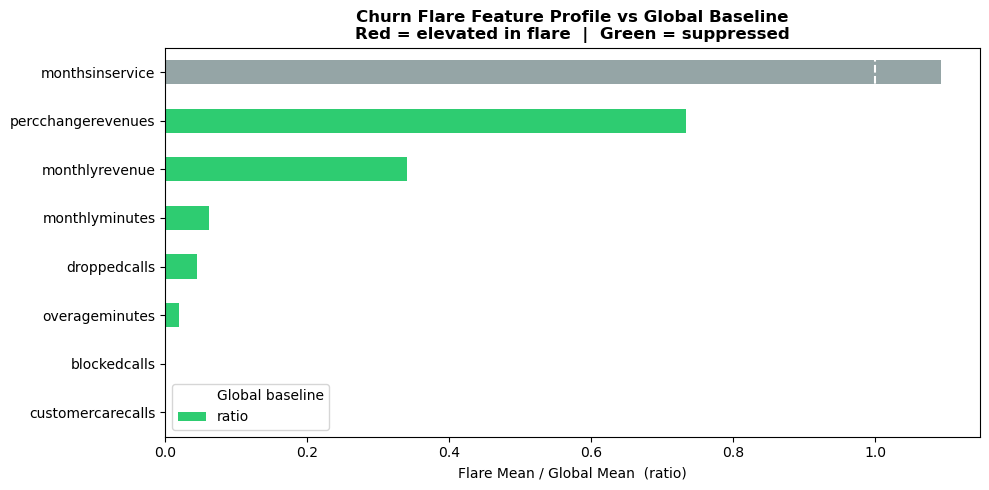

Chart saved to flare_profile.png


In [10]:
# Original flare detection — isolation score cr/(deg+1) picks the extreme tips
# of the churn flare: small, high-churn, disconnected nodes at the graph periphery.
# This is the correct topological approach — the flare TIP is the most extreme segment.
CHURN_FLARE_THRESHOLD = 0.45   # nodes with >= 45% churn rate
TOP_N_FLARE_NODES     = 6      # top 6 tip nodes by isolation score

degrees = dict(G.degree())

# Score: high churn + low connectivity = extreme flare tip
# Deliberately picks isolated high-churn nodes — the topological 'tip' of the flare
flare_scores = {}
for node in G.nodes():
    cr  = G.nodes[node].get('churn_rate', 0)
    deg = degrees[node]
    if cr >= CHURN_FLARE_THRESHOLD:
        flare_scores[node] = cr / (deg + 1)

flare_sorted      = sorted(flare_scores.items(), key=lambda x: -x[1])
top_flare_node_ids = [n for n, _ in flare_sorted[:TOP_N_FLARE_NODES]]

feat_profile_cols = [f for f in [
    'monthlyrevenue','monthlyminutes','customercarecalls','droppedcalls',
    'blockedcalls','overageminutes','monthsinservice','percchangerevenues',
] if f in X_imputed.columns]

# Collect all members from the top flare tip nodes
flare_member_indices = list(set(
    idx for node in top_flare_node_ids for idx in graph['nodes'].get(node, [])
))

flare_means       = X_imputed.iloc[flare_member_indices][feat_profile_cols].mean()
global_means_feat = X_imputed[feat_profile_cols].mean()
ratios            = (flare_means / (global_means_feat + 1e-9)).rename('ratio')

print(f'High-churn nodes (>= {CHURN_FLARE_THRESHOLD:.0%}): {len(flare_scores)}')
print()
print(f'{"Node":<30} {"Churn Rate":>12} {"Customers":>10} {"Churners":>10} {"Degree":>8} {"Score":>10}')
print('-' * 82)
for node, score in flare_sorted[:12]:
    nd = G.nodes[node]
    print(f'{node:<30} {nd.get("churn_rate",0):>12.1%} '
          f'{int(nd.get("size",0)):>10,} {int(nd.get("n_churners",0)):>10,} '
          f'{degrees[node]:>8} {score:>10.3f}')
print()
print(f'Top {TOP_N_FLARE_NODES} flare tip nodes selected')
print(f'Flare members   : {len(flare_member_indices):,}')
print(f'Flare churn rate: {df.iloc[flare_member_indices][CHURN_COL].mean():.1%}')
print(f'Global churn    : {y.mean():.1%}')
print(f'Enrichment      : {df.iloc[flare_member_indices][CHURN_COL].mean()/y.mean():.1f}x')

# Feature profile bar chart
fig2, ax2 = plt.subplots(figsize=(10, 5))
bar_cols = ['#e74c3c' if r > 1.1 else '#2ecc71' if r < 0.9 else '#95a5a6'
             for r in ratios.sort_values().values]
ratios.sort_values().plot(kind='barh', ax=ax2, color=bar_cols)
ax2.axvline(x=1.0, color='white', linestyle='--', linewidth=1.5, label='Global baseline')
ax2.set_xlabel('Flare Mean / Global Mean  (ratio)')
ax2.set_title(
    'Churn Flare Feature Profile vs Global Baseline\n'
    'Red = elevated in flare  |  Green = suppressed',
    fontweight='bold'
)
ax2.legend()
plt.tight_layout()
plt.savefig('flare_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to flare_profile.png')


---
## Stage 1E: Mapper Graph Visualisation

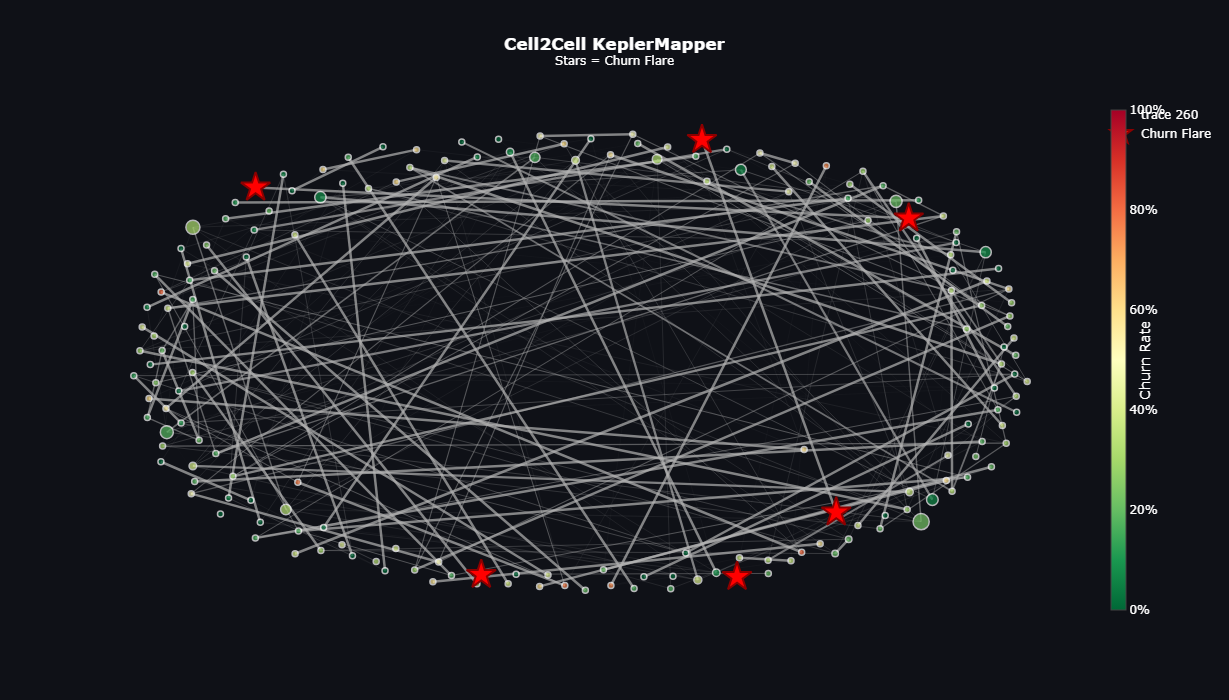

In [11]:
pos = nx.spring_layout(G, weight='weight', seed=42, k=1.8)
edge_traces = []
for u, v, d in G.edges(data=True):
    x0,y0=pos[u]; x1,y1=pos[v]
    alpha = 0.2 + d['weight']*0.5
    edge_traces.append(go.Scatter(x=[x0,x1,None],y=[y0,y1,None],mode='lines',
        line=dict(width=d['weight']*2.5,color=f'rgba(180,180,180,{alpha:.2f})'),
        hoverinfo='none',showlegend=False))

node_x,node_y,node_colors,node_sizes,node_texts=[],[],[],[],[]
for node in G.nodes():
    nd=G.nodes[node]; x,yp=pos[node]
    node_x.append(x); node_y.append(yp)
    node_colors.append(nd.get('churn_rate',0))
    node_sizes.append(max(6,min(45,nd.get('size',1)**0.55)))
    node_texts.append(f"<b>{node}</b><br>Customers: {int(nd.get('size',0)):,}<br>Churn: {nd.get('churn_rate',0):.1%}")

node_trace = go.Scatter(x=node_x,y=node_y,mode='markers',hoverinfo='text',text=node_texts,
    marker=dict(showscale=True,colorscale='RdYlGn_r',cmin=0,cmax=1,
                color=node_colors,size=node_sizes,
                colorbar=dict(thickness=15,title=dict(text='Churn Rate',side='right'),tickformat='.0%'),
                line=dict(width=1.5,color='white')))
flare_trace = go.Scatter(
    x=[pos[n][0] for n in top_flare_node_ids if n in pos],
    y=[pos[n][1] for n in top_flare_node_ids if n in pos],
    mode='markers',name='Churn Flare',
    marker=dict(symbol='star',size=22,color='red',line=dict(color='darkred',width=2)),
    hoverinfo='skip')

fig = go.Figure(
    data=edge_traces+[node_trace,flare_trace],
    layout=go.Layout(
        title=dict(text='<b>Cell2Cell KeplerMapper</b><br><sup>Stars = Churn Flare</sup>',x=0.5),
        height=700,showlegend=True,hovermode='closest',
        xaxis=dict(showgrid=False,zeroline=False,showticklabels=False),
        yaxis=dict(showgrid=False,zeroline=False,showticklabels=False),
        paper_bgcolor='#0f1117',plot_bgcolor='#0f1117',font=dict(color='white')))
fig.show()


---
## Stage 2: Topological Sample Extraction

In [12]:
flare_sample_df = df.iloc[flare_member_indices].copy()
flare_sample_df['churn_proba'] = churn_proba[flare_member_indices]
flare_sample_df = flare_sample_df.sort_values('churn_proba', ascending=False)
TOPO_SAMPLE_SIZE = 200
topo_sample = flare_sample_df.head(TOPO_SAMPLE_SIZE)
topo_churn_rate   = float(topo_sample[CHURN_COL].mean())
global_churn_rate = float(y.mean())
enrichment        = topo_churn_rate / global_churn_rate
full_df = df.copy()  # keep in memory for DoWhy

print(f'Flare members : {len(flare_sample_df):,}')
print(f'Sample size   : {len(topo_sample)}')
print(f'Churn rate    : {topo_churn_rate:.1%}  (global: {global_churn_rate:.1%})')
print(f'Enrichment    : {enrichment:.1f}x')

FEAT_DESCS = {
    'monthlyrevenue':        'Total monthly revenue billed to customer ($)',
    'monthlyminutes':        'Total call minutes used in the month',
    'customercarecalls':     'Number of inbound calls to customer care (dissatisfaction proxy)',
    'droppedcalls':          'Number of dropped calls (network quality failure)',
    'blockedcalls':          'Number of blocked calls (network congestion)',
    'overageminutes':        'Minutes used beyond plan limit (pricing friction)',
    'percchangerevenues':    'Month-over-month % change in revenue (engagement trend)',
    'percchangeminutes':     'Month-over-month % change in call minutes',
    'monthsinservice':       'Tenure in months (customer age)',
    'roamingcalls':          'Number of roaming calls (service area expansion)',
    'directorassistedcalls': 'Calls requiring directory assistance (complexity/friction)',
    'retentioncall':         'Whether customer received a retention call (1=Yes)',
    'retentionoffer':        'Whether customer received a retention offer (1=Yes)',
    'madecalltoretentionteam':'Whether customer proactively called retention team (1=Yes)',
}
FLARE_STATS = {
    'total_flare_customers': len(flare_sample_df),
    'topo_churn_rate':       topo_churn_rate,
    'global_churn_rate':     global_churn_rate,
    'enrichment':            enrichment,
    'top_elevated_features': ratios.sort_values(ascending=False).head(5).to_dict(),
}
print('FLARE_STATS and FEAT_DESCS ready - no CSV handoff needed')


Flare members : 20
Sample size   : 20
Churn rate    : 70.0%  (global: 28.8%)
Enrichment    : 2.4x
FLARE_STATS and FEAT_DESCS ready - no CSV handoff needed


---
## Stage 2B: Churn Prediction Validation + Topological Risk Scoring

The Duke `cell2cellholdout.csv` is an **intentionally unlabelled** prediction competition file — all churn values are 0. We can't use it for accuracy measurement.

Instead we validate two ways:

**1. Stratified train/val split** — hold out 20% of the labelled training data to get honest AUC, precision, and recall on known churners.

**2. Topological proximity risk score** — customers who sit close to the churn flare in the mapper graph are *topologically at risk* even if the GBM hasn't flagged them yet. We score every customer by weighted proximity to flare nodes (flare=3x, 1-hop=2x, 2-hop=1.5x) to build a risk tier that is independent of the predictive model.

PART 1: LABELLED VALIDATION (stratified 20% of training data)
Val set size     : 10,210  (20% of training data)
Val churn rate   : 28.8%  (expected ~28.8% — stratified)
Val AUC-ROC      : 0.6750
Train AUC        : 0.6750  (overfit gap: +0.0000)

              precision    recall  f1-score   support

    No Churn       0.73      0.97      0.83      7268
       Churn       0.59      0.12      0.20      2942

    accuracy                           0.72     10210
   macro avg       0.66      0.54      0.52     10210
weighted avg       0.69      0.72      0.65     10210



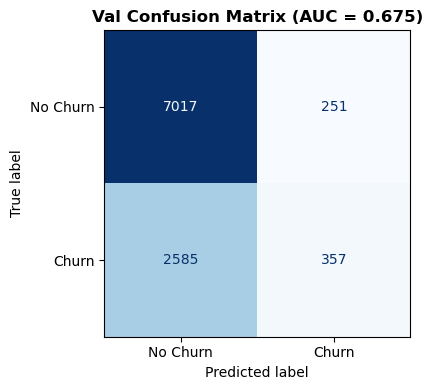

PART 2: TOPOLOGICAL PROXIMITY RISK SCORING
Scoring customers by proximity to the churn flare in the mapper graph.
Independent of the GBM model — purely topological.

Flare nodes : 6
1-hop nodes : 0
2-hop nodes : 0
Computing topological risk scores...

Topological Risk Tiers:
           customers  churn_rate  avg_gbm
topo_tier                                
Low            50452       0.287    0.287
Medium           473       0.311    0.342
High              82       0.524    0.422
Critical          40       0.775    0.542

Actual churners topology found but GBM missed: 13
At-risk pool (topo High/Critical OR GBM>=0.5): 3,200 customers
Churn rate in pool: 72.2%


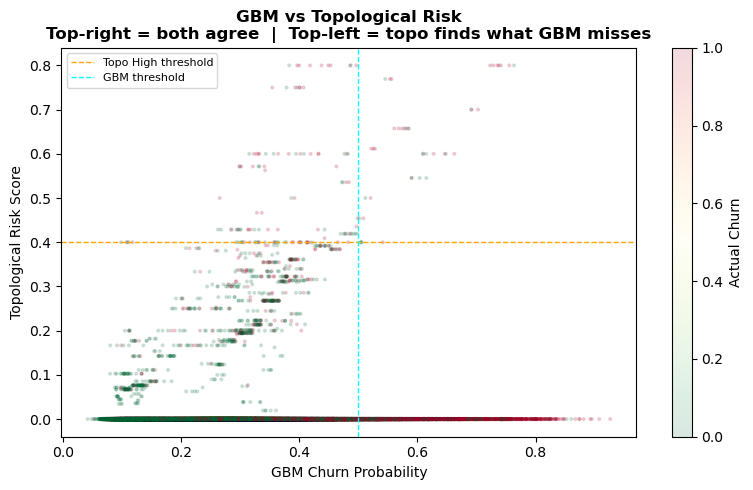


holdout variable set for Stage 2C recommender (topo+GBM at-risk pool)


In [13]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ─────────────────────────────────────────────────────────────────────────
# PART 1: Labelled validation on stratified 20% holdout from training data
# ─────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('PART 1: LABELLED VALIDATION (stratified 20% of training data)')
print('=' * 60)

X_tr80, X_val, y_tr80, y_val = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
# Train a fresh model on 80% so the val set is genuinely unseen
gbm_val = GradientBoostingClassifier(
    n_estimators=150, max_depth=4, random_state=42, subsample=0.8
)
gbm_val.fit(X_tr80, y_tr80)

y_val_proba = gbm_val.predict_proba(X_val)[:, 1]
y_val_pred  = (y_val_proba >= 0.5).astype(int)
val_auc     = roc_auc_score(y_val, y_val_proba)

print(f'Val set size     : {len(y_val):,}  ({len(y_val)/len(y):.0%} of training data)')
print(f'Val churn rate   : {y_val.mean():.1%}  (expected ~{y.mean():.1%} — stratified)')
print(f'Val AUC-ROC      : {val_auc:.4f}')
print(f'Train AUC        : {global_auc:.4f}  (overfit gap: {global_auc - val_auc:+.4f})')
print()
print(classification_report(y_val, y_val_pred, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_val_pred),
    display_labels=['No Churn', 'Churn']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Val Confusion Matrix (AUC = {val_auc:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig('val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────
# PART 2: Topological proximity risk scoring on the full training set
# ─────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('PART 2: TOPOLOGICAL PROXIMITY RISK SCORING')
print('=' * 60)
print('Scoring customers by proximity to the churn flare in the mapper graph.')
print('Independent of the GBM model — purely topological.')
print()

# Build customer -> nodes lookup
customer_to_nodes = {}
for node_id, members in graph['nodes'].items():
    for idx in members:
        customer_to_nodes.setdefault(idx, []).append(node_id)

flare_node_set = set(top_flare_node_ids)

# Expand to 1-hop and 2-hop neighbours in the mapper graph
hop1_nodes = set()
for fnode in flare_node_set:
    for nbr in G.neighbors(fnode):
        if nbr not in flare_node_set:
            hop1_nodes.add(nbr)

hop2_nodes = set()
for h1 in hop1_nodes:
    for nbr in G.neighbors(h1):
        if nbr not in flare_node_set and nbr not in hop1_nodes:
            hop2_nodes.add(nbr)

print(f'Flare nodes : {len(flare_node_set)}')
print(f'1-hop nodes : {len(hop1_nodes)}')
print(f'2-hop nodes : {len(hop2_nodes)}')

def topo_risk(cust_idx):
    """Weighted proximity to churn flare: flare=3x, hop1=2x, hop2=1.5x, other=1x."""
    nodes = customer_to_nodes.get(cust_idx, [])
    if not nodes:
        return 0.0
    total, weight_sum = 0.0, 0.0
    for n in nodes:
        cr = G.nodes[n].get('churn_rate', 0)
        w  = 3.0 if n in flare_node_set else 2.0 if n in hop1_nodes else 1.5 if n in hop2_nodes else 1.0
        total      += cr * w
        weight_sum += w
    return total / weight_sum if weight_sum > 0 else 0.0

print('Computing topological risk scores...')
topo_scores = {idx: topo_risk(idx) for idx in range(len(df))}
df['topo_risk'] = pd.Series(topo_scores)

# Risk tiers
df['topo_tier'] = pd.cut(
    df['topo_risk'],
    bins  = [-0.001, 0.20, 0.40, 0.60, 1.01],
    labels= ['Low', 'Medium', 'High', 'Critical']
)

tier_summary = df.groupby('topo_tier', observed=True).agg(
    customers =(CHURN_COL, 'count'),
    churn_rate=(CHURN_COL, 'mean'),
    avg_gbm   =('churn_proba', 'mean')
).round(3)
print()
print('Topological Risk Tiers:')
print(tier_summary.to_string())

# Customers the GBM missed but topology flagged as Critical
topo_only = df[
    (df['topo_tier'] == 'Critical') &
    (df['churn_proba'] < 0.5) &
    (df[CHURN_COL] == 1)
]
print(f'\nActual churners topology found but GBM missed: {len(topo_only):,}')

# Save topo-scored dataset for the recommender
# Use Critical + High topo-risk customers as the 'at-risk' pool for Stage 2C
at_risk_topo = df[
    (df['topo_tier'].isin(['Critical', 'High'])) |
    (df['churn_proba'] >= 0.5)
].copy()
print(f'At-risk pool (topo High/Critical OR GBM>=0.5): {len(at_risk_topo):,} customers')
print(f'Churn rate in pool: {at_risk_topo[CHURN_COL].mean():.1%}')

# Visualise topo risk vs GBM proba
fig2, ax2 = plt.subplots(figsize=(8, 5))
scatter = ax2.scatter(
    df['churn_proba'], df['topo_risk'],
    c=df[CHURN_COL], cmap='RdYlGn_r',
    alpha=0.15, s=4
)
ax2.axhline(0.40, color='orange', linewidth=1, linestyle='--', label='Topo High threshold')
ax2.axvline(0.50, color='cyan',   linewidth=1, linestyle='--', label='GBM threshold')
ax2.set_xlabel('GBM Churn Probability')
ax2.set_ylabel('Topological Risk Score')
ax2.set_title('GBM vs Topological Risk\n'
              'Top-right = both agree  |  Top-left = topo finds what GBM misses',
              fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Actual Churn')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig('topo_vs_gbm_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Use at_risk_topo as holdout for Stage 2C recommender
holdout = at_risk_topo.copy()
holdout['churn_pred'] = (holdout['churn_proba'] >= 0.5).astype(int)
HOLDOUT_CHURN = CHURN_COL
holdout_feat_cols = FEATURE_COLS
print('\nholdout variable set for Stage 2C recommender (topo+GBM at-risk pool)')


---
## Stage 2C: Rule-Based Action Recommender

Based on **Duan & Ras (2022)** action-rule mining.

In [14]:
ACTION_CATALOGUE = {
    'droppedcalls':           ('decrease','Escalate to network ops for coverage improvement',        'Network Ops'),
    'blockedcalls':           ('decrease','Upgrade cell capacity in customer usage area',             'Network Ops'),
    'droppedblockdcalls':     ('decrease','Priority network audit + SLA callback within 48 hrs',     'Network Ops'),
    'overageminutes':         ('decrease','Proactively offer plan upgrade to eliminate overage',      'Sales'),
    'totalrecurringcharge':   ('decrease','Apply loyalty discount or match competitor pricing',       'Sales'),
    'monthlyrevenue':         ('increase','Bundle additional services at no cost to boost value',     'Sales'),
    'directorassistedcalls':  ('decrease','Enable self-service directory app + customer education',   'Digital'),
    'customercarecalls':      ('decrease','Root-cause complaint history; assign dedicated account mgr','Retention'),
    'monthlyminutes':         ('increase','Offer free minutes bundle to re-engage usage',             'Marketing'),
    'percchangeminutes':      ('increase','Trigger win-back campaign if usage declining >20% MoM',   'Marketing'),
    'percchangerevenues':     ('increase','Offer loyalty reward tied to maintaining current spend',   'Marketing'),
    'retentioncall':          ('increase','Schedule proactive outbound retention call within 7 days', 'Retention'),
    'retentionoffer':         ('increase','Prepare personalised retention offer (discount/upgrade)',  'Retention'),
    'madecalltoretentionteam':('increase','Fast-track to senior retention agent; log complaint',      'Retention'),
    'currentequipmentdays':   ('decrease','Offer early handset upgrade at subsidised price',          'Sales'),
    'monthsinservice':        ('increase','Enrol in loyalty tier programme with milestone rewards',   'Marketing'),
}

PROXY_KEYWORDS = ['proxy','symptom','indicator','signal','surrogate']
def is_proxy(feat):
    return any(kw in FEAT_DESCS.get(feat,'').lower() for kw in PROXY_KEYWORDS)

global_feat_means = X_imputed[[c for c in holdout_feat_cols if c in X_imputed.columns]].mean()
global_feat_stds  = X_imputed[[c for c in holdout_feat_cols if c in X_imputed.columns]].std()

def generate_recommendations(customer_row, top_n=3):
    recs = []
    for feat, (direction, action, team) in ACTION_CATALOGUE.items():
        if feat not in customer_row.index or feat not in global_feat_means.index: continue
        val   = customer_row[feat]
        mean_v = global_feat_means[feat]
        std_v  = global_feat_stds[feat] + 1e-9
        dev    = (val - mean_v) / std_v
        if direction == 'decrease' and dev > 0.3:   impact = dev
        elif direction == 'increase' and dev < -0.3: impact = abs(dev)
        else: continue
        recs.append({'feature':feat,'direction':direction,'current_val':round(float(val),2),
                     'global_mean':round(float(mean_v),2),'action':action,'owner':team,
                     'impact_score':round(impact,3),'is_proxy':is_proxy(feat)})
    recs.sort(key=lambda x: -x['impact_score'])
    return recs[:top_n]

AT_RISK_THRESHOLD = 0.5
at_risk = holdout[holdout['churn_proba'] >= AT_RISK_THRESHOLD].copy()
print(f'At-risk customers (proba >= {AT_RISK_THRESHOLD}): {len(at_risk):,}')

all_recs = []
for idx, row in at_risk.iterrows():
    for r in generate_recommendations(row):
        r['customer_idx'] = idx
        r['churn_proba']  = row['churn_proba']
        all_recs.append(r)

recs_df = pd.DataFrame(all_recs)
print(f'Total recommendations: {len(recs_df):,}')

portfolio = (recs_df.groupby(['owner','action'])
             .agg(customers_affected=('customer_idx','nunique'),
                  avg_impact=('impact_score','mean'))
             .sort_values('customers_affected',ascending=False).reset_index())
print('\nTOP PORTFOLIO ACTIONS:')
print(portfolio.head(8).to_string(index=False))
recs_df.to_csv('action_recommendations.csv', index=False)
print('\nSaved action_recommendations.csv')


At-risk customers (proba >= 0.5): 3,116
Total recommendations: 8,971

TOP PORTFOLIO ACTIONS:
      owner                                                 action  customers_affected  avg_impact
  Marketing           Offer free minutes bundle to re-engage usage                1765    0.840388
  Marketing Enrol in loyalty tier programme with milestone rewards                1391    0.720492
      Sales   Bundle additional services at no cost to boost value                1344    0.781529
      Sales        Offer early handset upgrade at subsidised price                 965    1.701219
  Marketing  Trigger win-back campaign if usage declining >20% MoM                 950    1.547396
      Sales    Proactively offer plan upgrade to eliminate overage                 560    2.120454
  Marketing Offer loyalty reward tied to maintaining current spend                 474    1.442888
Network Ops       Escalate to network ops for coverage improvement                 467    1.903456

Saved action_re

---
## Stage 3: LLM Causal Discovery

LLM receives the churn flare profile and proposes a causal DAG (no CSV handoff - uses in-memory data).

In [15]:
flare = topo_sample.copy()
numeric_cols = flare.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols
                if c not in [CHURN_COL,'customerid','churn_proba','is_in_flare']
                and flare[c].std() > 0]
causal_feats = [f for f in FEAT_DESCS.keys() if f in numeric_cols]

flare_means_c  = flare[causal_feats].mean()
global_means_c = full_df[causal_feats].mean()
ratios_c       = flare_means_c / (global_means_c.abs() + 1e-9)

profile_lines = []
for feat in causal_feats:
    r = ratios_c.get(feat, 1)
    direction = 'ELEVATED' if r > 1.1 else 'SUPPRESSED' if r < 0.9 else 'NORMAL'
    profile_lines.append(
        f'  {feat}: flare={flare_means_c.get(feat,0):.2f}, '
        f'global={global_means_c.get(feat,0):.2f}, ratio={r:.2f} [{direction}]'
    )

profile_str   = '\n'.join(profile_lines)
feat_desc_str = '\n'.join(f'  - {f}: {d}' for f,d in FEAT_DESCS.items() if f in causal_feats)

SYSTEM_PROMPT_DAG = (
    'You are a causal reasoning expert specializing in telecom customer behavior.\n'
    'You reason about causal mechanisms using domain knowledge, not just statistics.\n'
    'You output ONLY valid JSON - no prose, no markdown fences.'
)

USER_PROMPT_DAG = (
    f'I identified a high-churn cluster ("churn flare") using TDA.\n'
    f'Churn rate: {FLARE_STATS["topo_churn_rate"]:.0%} vs {FLARE_STATS["global_churn_rate"]:.0%} globally.\n\n'
    f'FEATURE DESCRIPTIONS:\n{feat_desc_str}\n\n'
    f'FLARE PROFILE (flare mean vs global mean):\n{profile_str}\n\n'
    f'TASK: Propose a causal DAG explaining WHY these customers churn.\n'
    f'Outcome node must be "{CHURN_COL}". Include 4-8 edges max.\n\n'
    'Respond ONLY with:\n'
    '{\n'
    '  "edges": [["cause","effect"], ...],\n'
    '  "reasoning": {"cause__effect": "one-line explanation", ...},\n'
    '  "primary_treatment": "most actionable feature",\n'
    '  "causal_story": "2-3 sentence summary"\n'
    '}'
)

print('Running LLM causal DAG inference...')
print(f'Prompt length: ~{len(USER_PROMPT_DAG)} chars')
print()
raw_response = call_llm_json(USER_PROMPT_DAG, SYSTEM_PROMPT_DAG)
print('\nRaw response:')
print(raw_response[:500])


Running LLM causal DAG inference...
Prompt length: ~1731 chars

  Attempt 1/3... 

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


24.5s

Raw response:
{
  "edges": [["monthlyrevenue", "churn"], ["percchangeminutes", "churn"], ["monthsinservice", "churn"], ["droppedcalls", "churn"]],
  "reasoning": {
    "monthlyrevenue__churn": "High churn is driven by low revenue, indicating financial distress.",
    "percchangeminutes__churn": "Declining usage suggests dissatisfaction or loss of interest.",
    "monthsinservice__churn": "Longer tenure customers are more likely to churn due to attrition.",
    "droppedcalls__churn": "More dropped calls correl


In [16]:
clean   = re.sub(r'```(?:json)?\s*', '', raw_response).strip()
llm_dag = json.loads(clean)
edges     = llm_dag['edges']
reasoning = llm_dag.get('reasoning', {})
treatment = llm_dag['primary_treatment']
story     = llm_dag['causal_story']

known = set(causal_feats) | {CHURN_COL}
edges = [(u,v) for u,v in edges if u in known and v in known]
G_dag = nx.DiGraph()
G_dag.add_nodes_from(known)
G_dag.add_edges_from(edges)
if not nx.is_directed_acyclic_graph(G_dag):
    print('Cycle detected - removing back-edges')
    for cycle in list(nx.simple_cycles(G_dag)):
        G_dag.remove_edge(cycle[-1], cycle[0])
    edges = list(G_dag.edges())

print('=' * 55)
print('LLM CAUSAL DAG')
print('=' * 55)
for u, v in edges:
    label = reasoning.get(f'{u}__{v}', reasoning.get(f'{u} -> {v}', ''))
    print(f'  {u} -> {v}  {"("+label+")" if label else ""}')
print(f'\nPrimary treatment: {treatment}')
print(f'\nCausal story:')
print(textwrap.fill(story, width=65, initial_indent='  ', subsequent_indent='  '))


LLM CAUSAL DAG
  monthlyrevenue -> churn  (High churn is driven by low revenue, indicating financial distress.)
  percchangeminutes -> churn  (Declining usage suggests dissatisfaction or loss of interest.)
  monthsinservice -> churn  (Longer tenure customers are more likely to churn due to attrition.)
  droppedcalls -> churn  (More dropped calls correlate with poor service quality and higher churn.)

Primary treatment: monthsinservice

Causal story:
  Customers with longer tenure are more susceptible to churn,
  exacerbated by declining revenue and increasing dropped calls,
  leading to overall dissatisfaction.


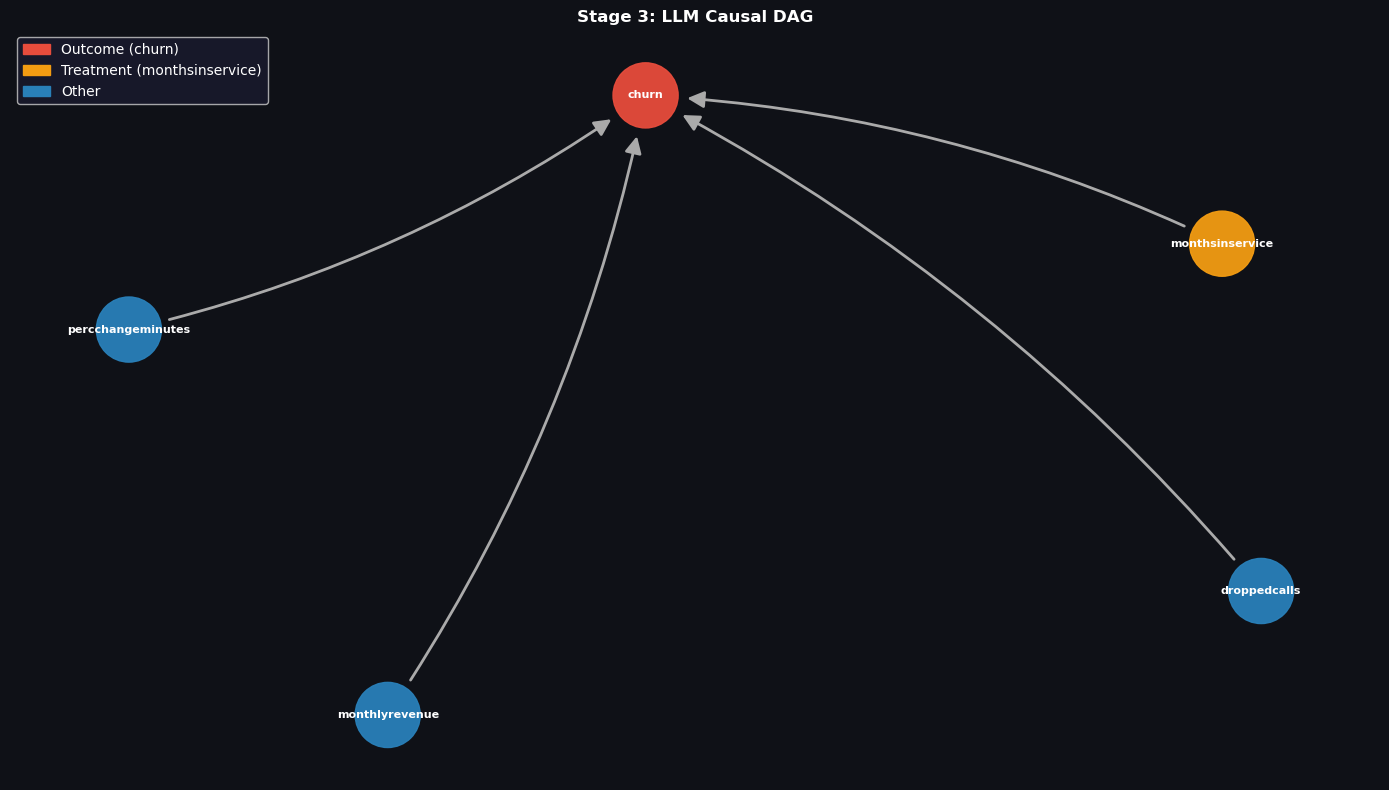

In [17]:
fig, ax = plt.subplots(figsize=(14,8))
ax.set_facecolor('#0f1117'); fig.patch.set_facecolor('#0f1117')
dag_nodes = [n for n in G_dag.nodes() if G_dag.degree(n) > 0]
G_plot    = G_dag.subgraph(dag_nodes)
try:
    pos = nx.nx_agraph.graphviz_layout(G_plot, prog='dot')
except Exception:
    pos = nx.spring_layout(G_plot, seed=42, k=3)
node_colors = ['#e74c3c' if n==CHURN_COL else '#f39c12' if n==treatment else '#2980b9'
               for n in G_plot.nodes()]
nx.draw_networkx_nodes(G_plot,pos,ax=ax,node_color=node_colors,node_size=2200,alpha=0.95)
nx.draw_networkx_labels(G_plot,pos,ax=ax,font_color='white',font_size=8,font_weight='bold')
nx.draw_networkx_edges(G_plot,pos,ax=ax,edge_color='#aaaaaa',arrows=True,
    arrowsize=25,arrowstyle='-|>',connectionstyle='arc3,rad=0.1',
    width=2,min_source_margin=30,min_target_margin=30)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c',label='Outcome (churn)'),
    mpatches.Patch(color='#f39c12',label=f'Treatment ({treatment})'),
    mpatches.Patch(color='#2980b9',label='Other'),
], loc='upper left', facecolor='#1a1a2e', labelcolor='white')
ax.set_title('Stage 3: LLM Causal DAG', color='white', fontweight='bold', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('llm_dag.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


---
## Stage 4: Statistical Estimation with DoWhy

In [18]:
def to_dot_id(name): return '"' + name + '"'
dot_edges   = '; '.join(f'{to_dot_id(u)} -> {to_dot_id(v)}' for u,v in edges)
dowhy_graph = f'digraph {{ {dot_edges} }}'
print('DoWhy graph:', dowhy_graph)

direct_treatments = [u for u,v in edges if v == CHURN_COL]
print(f'Direct causes: {direct_treatments}')

if 'churn_proba' in full_df.columns:
    DOWHY_DATA = full_df[full_df['churn_proba'] > 0.4]
else:
    DOWHY_DATA = full_df
DOWHY_DATA = DOWHY_DATA[[c for c in full_df.columns
                          if c in list(G_dag.nodes()) + [CHURN_COL]]].dropna()
print(f'DoWhy dataset: {len(DOWHY_DATA):,} customers | churn: {DOWHY_DATA[CHURN_COL].mean():.1%}')


DoWhy graph: digraph { "monthlyrevenue" -> "churn"; "percchangeminutes" -> "churn"; "monthsinservice" -> "churn"; "droppedcalls" -> "churn" }
Direct causes: ['monthlyrevenue', 'percchangeminutes', 'monthsinservice', 'droppedcalls']
DoWhy dataset: 8,530 customers | churn: 58.3%


In [19]:
results = []
for treat in direct_treatments:
    print(f'\n{chr(9472)*55}')
    print(f'Treatment: {treat} -> {CHURN_COL}')
    try:
        causal_model = CausalModel(  # causal_model to avoid clash with llm_model
            data=DOWHY_DATA, treatment=treat, outcome=CHURN_COL, graph=dowhy_graph)
        identified = causal_model.identify_effect(proceed_when_unidentifiable=True)
        estimate   = causal_model.estimate_effect(
            identified, method_name='backdoor.linear_regression',
            target_units='ate', confidence_intervals=True)
        ate = estimate.value
        print(f'ATE: {ate:.6f}')

        refute_p = causal_model.refute_estimate(identified, estimate,
            method_name='placebo_treatment_refuter', placebo_type='permute', num_simulations=20)
        refute_r = causal_model.refute_estimate(identified, estimate,
            method_name='random_common_cause', num_simulations=20)
        placebo_ate = refute_p.new_effect
        rcc_ate     = refute_r.new_effect
        pct_change  = abs(rcc_ate - ate) / (abs(ate) + 1e-10) * 100
        print(f'Placebo: {placebo_ate:.6f}  {"pass" if abs(placebo_ate)<abs(ate)*0.3 else "weak"}')
        print(f'RCC:     {rcc_ate:.6f}  ({pct_change:.1f}% change)')
        results.append({'treatment':treat,'outcome':CHURN_COL,'ate':ate,
                        'placebo_ate':placebo_ate,'rcc_ate':rcc_ate,
                        'placebo_passes':abs(placebo_ate)<abs(ate)*0.3,
                        'rcc_robust':pct_change<15})
    except Exception as e:
        print(f'Error: {e}')
        results.append({'treatment':treat,'outcome':CHURN_COL,'ate':None,'error':str(e)})

results_df = pd.DataFrame(results)
print('\n' + '='*55)
print(results_df[['treatment','ate','placebo_passes','rcc_robust']].to_string())



───────────────────────────────────────────────────────
Treatment: monthlyrevenue -> churn
ATE: 0.000302
Placebo: -0.000022  pass
RCC:     0.000302  (0.1% change)

───────────────────────────────────────────────────────
Treatment: percchangeminutes -> churn
ATE: -0.000035
Placebo: 0.000001  pass
RCC:     -0.000035  (0.1% change)

───────────────────────────────────────────────────────
Treatment: monthsinservice -> churn
ATE: 0.000442
Placebo: 0.000059  pass
RCC:     0.000442  (0.0% change)

───────────────────────────────────────────────────────
Treatment: droppedcalls -> churn
ATE: 0.000395
Placebo: -0.000029  pass
RCC:     0.000397  (0.4% change)

           treatment       ate  placebo_passes  rcc_robust
0     monthlyrevenue  0.000302            True        True
1  percchangeminutes -0.000035            True        True
2    monthsinservice  0.000442            True        True
3       droppedcalls  0.000395            True        True


In [20]:
valid = results_df[results_df['ate'].notna()].copy()
feat_stds = full_df[[c for c in direct_treatments if c in full_df.columns]].std()

interventions = []
for _, row in valid.iterrows():
    treat = row['treatment']
    ate   = row['ate']
    if treat not in feat_stds.index: continue
    std        = feat_stds[treat]
    effect_1sd = ate * std
    pct_change = effect_1sd / FLARE_STATS['topo_churn_rate'] * 100
    robust     = row.get('placebo_passes') and row.get('rcc_robust')
    proxy      = is_proxy(treat)
    sign       = 'DOWN' if effect_1sd < 0 else 'UP'
    print(f'[{sign}] {treat}')
    print(f'   ATE: {ate:+.5f} | 1-SD impact: {abs(pct_change):.1f}% | Robust: {"Yes" if robust else "No"}')
    if proxy:
        print(f'   PROXY - address root cause, not the metric itself')
    else:
        direction = 'Reducing' if ate > 0 else 'Increasing'
        print(f'   -> {direction} by 1 SD reduces churn by {abs(pct_change):.1f}%')
    print()
    interventions.append({'feature':treat,'ate_per_unit':ate,'effect_1sd':effect_1sd,
                          'pct_churn_change':pct_change,'robust':robust,'is_proxy':proxy})

interventions_df = pd.DataFrame(interventions)
print('Causal story:')
print(textwrap.fill(story, width=70))


[UP] monthlyrevenue
   ATE: +0.00030 | 1-SD impact: 1.9% | Robust: Yes
   -> Reducing by 1 SD reduces churn by 1.9%

[DOWN] percchangeminutes
   ATE: -0.00003 | 1-SD impact: 1.3% | Robust: Yes
   -> Increasing by 1 SD reduces churn by 1.3%

[UP] monthsinservice
   ATE: +0.00044 | 1-SD impact: 0.6% | Robust: Yes
   -> Reducing by 1 SD reduces churn by 0.6%

[UP] droppedcalls
   ATE: +0.00040 | 1-SD impact: 0.5% | Robust: Yes
   -> Reducing by 1 SD reduces churn by 0.5%

Causal story:
Customers with longer tenure are more susceptible to churn,
exacerbated by declining revenue and increasing dropped calls, leading
to overall dissatisfaction.


---
## Stage 5: LLM-Enhanced Action Recommender

Closes the loop between causal inference and retention actions.
For each at-risk customer the LLM:
1. Validates whether each rule-based action is a **root cause, mediator, or symptom**
2. Flags missed interventions from the causal evidence
3. Writes a ready-to-use **retention pitch** for the agent

Implements the **meta-action triggering** mechanism from Duan & Ras (2022).

In [21]:
SYSTEM_PROMPT_REC = (
    'You are a senior telecom retention strategist with expertise in causal inference.\n'
    'You receive a causal DAG, DoWhy ATE estimates, a customer profile, and rule-based recommendations.\n'
    'Validate each action (root_cause/mediator/symptom/unrelated), suggest missed interventions,\n'
    'and write a 2-sentence retention pitch. Output ONLY valid JSON.'
)

causal_context_str = '\n'.join([
    f'  {r["treatment"]} -> churn: ATE={r["ate"]:+.5f} '
    f'(placebo={"pass" if r["placebo_passes"] else "weak"}, rcc={"robust" if r["rcc_robust"] else "sensitive"})'
    for _, r in results_df.iterrows() if pd.notna(r['ate'])
])
dag_edges_str = '\n'.join(f'  {u} -> {v}' for u,v in edges)

PROFILE_FEATS = [f for f in [
    'monthlyrevenue','monthlyminutes','customercarecalls','droppedcalls',
    'overageminutes','monthsinservice','retentioncall','retentionoffer',
    'percchangerevenues','totalrecurringcharge','blockedcalls','currentequipmentdays'
] if f in holdout.columns]

def build_rec_prompt(profile, rule_recs):
    profile_str = '\n'.join(
        f'  {k}: {v:.2f}' if isinstance(v, float) else f'  {k}: {v}'
        for k, v in profile.items()
    )
    recs_str = '\n'.join(
        f'  [{i+1}] {r["feature"]} | {r["action"]} | Owner: {r["owner"]} | '
        f'Impact: {r["impact_score"]:.2f}sigma | Proxy: {r["is_proxy"]}'
        for i, r in enumerate(rule_recs)
    )
    return (
        f'CAUSAL DAG:\n{dag_edges_str}\n\n'
        f'DOWHY ATE ESTIMATES:\n{causal_context_str}\n\n'
        f'CAUSAL STORY:\n{story}\n\n'
        f'CUSTOMER PROFILE (churn probability: {profile.get("churn_proba","?")})'  
        f':\n{profile_str}\n\n'
        f'RULE-BASED RECOMMENDATIONS:\n{recs_str}\n\n'
        'Respond ONLY with:\n'
        '{\n'
        '  "action_assessments": [{"rank":1,"feature":"...",'
        '"causal_validity":"root_cause|mediator|symptom|unrelated",'
        '"llm_verdict":"approve|modify|reject","reasoning":"one sentence",'
        '"enhanced_action":"refined action if needed"}],\n'
        '  "missed_interventions": [{"feature":"...","action":"...","reasoning":"..."}],\n'
        '  "priority_action": "single most impactful action",\n'
        '  "estimated_churn_reduction": "low|medium|high",\n'
        '  "retention_narrative": "2-sentence pitch for the retention agent"\n'
        '}'
    )

TOP_CUSTOMERS = 5  # increase once confirmed working
top_cust_idxs = (recs_df.sort_values('churn_proba', ascending=False)
                 ['customer_idx'].drop_duplicates().head(TOP_CUSTOMERS).tolist())

print('=' * 65)
print('LLM-ENHANCED ACTION RECOMMENDATIONS')
print('=' * 65)

enhanced_results = []
for cust_idx in top_cust_idxs:
    cust_recs = recs_df[recs_df['customer_idx'] == cust_idx].to_dict('records')
    if not cust_recs: continue
    churn_p = cust_recs[0]['churn_proba']
    print(f'\n{chr(9472)*65}')
    print(f'Customer {cust_idx}  |  Churn probability: {churn_p:.1%}')

    if cust_idx in holdout.index:
        cust_row = holdout.loc[cust_idx]
        profile  = {f: float(cust_row[f]) for f in PROFILE_FEATS
                    if f in cust_row.index and pd.notna(cust_row[f])}
    else:
        profile  = {r['feature']: r['current_val'] for r in cust_recs}
    profile['churn_proba'] = round(churn_p, 4)

    raw = call_llm_json(build_rec_prompt(profile, cust_recs), SYSTEM_PROMPT_REC, max_retries=2)

    try:
        clean  = re.sub(r'```(?:json)?\s*', '', raw).strip()
        match  = re.search(r'(\{.*\})', clean, re.DOTALL)
        result = json.loads(match.group(1)) if match else {}
        print(f'  Priority  : {result.get("priority_action","N/A")}')
        print(f'  Est impact: {result.get("estimated_churn_reduction","N/A")}')
        print(f'  Pitch     : {result.get("retention_narrative","")[:120]}')
        for a in result.get('action_assessments', []):
            icon = 'OK' if a.get('llm_verdict')=='approve' else 'MOD' if a.get('llm_verdict')=='modify' else 'REJ'
            print(f'  [{icon}] [{a.get("causal_validity","?")}] {a.get("feature","")} -> {a.get("llm_verdict","")}')
            print(f'       {a.get("reasoning","")}')
            if a.get('llm_verdict') in ('modify','reject'):
                print(f'       Enhanced: {a.get("enhanced_action","")}')
        for m in result.get('missed_interventions', []):
            print(f'  + MISSED: {m.get("feature","")} -> {m.get("action","")}')
        result['customer_idx'] = cust_idx
        result['churn_proba']  = churn_p
        enhanced_results.append(result)
    except Exception as e:
        print(f'  Parse error: {e}')

if enhanced_results:
    rows = []
    for r in enhanced_results:
        for a in r.get('action_assessments', []):
            rows.append({
                'customer_idx':        r['customer_idx'],
                'churn_proba':         r['churn_proba'],
                'feature':             a.get('feature'),
                'causal_validity':     a.get('causal_validity'),
                'llm_verdict':         a.get('llm_verdict'),
                'reasoning':           a.get('reasoning'),
                'enhanced_action':     a.get('enhanced_action', ''),
                'priority_action':     r.get('priority_action'),
                'churn_reduction_est': r.get('estimated_churn_reduction'),
                'retention_narrative': r.get('retention_narrative'),
            })
    pd.DataFrame(rows).to_csv('llm_enhanced_recommendations.csv', index=False)
    print(f'\nSaved llm_enhanced_recommendations.csv')
    print(f'{len(enhanced_results)} customers | {len(rows)} action assessments')


LLM-ENHANCED ACTION RECOMMENDATIONS

─────────────────────────────────────────────────────────────────
Customer 12036  |  Churn probability: 92.6%
  Attempt 1/2... 35.1s
  Priority  : Offer bundled services or discounts to enhance customer value
  Est impact: high
  Pitch     : By focusing on boosting customer value through bundled services and discounts, we can effectively mitigate the root caus
  [OK] [root_cause] monthlyrevenue -> approve
       The impact of monthly revenue on churn is significant, indicating it's a key factor.
  [OK] [mediator] percchangeminutes -> approve
       While not directly causing churn, changes in minutes usage can indirectly affect customer satisfaction.
  [OK] [symptom] monthsinservice -> approve
       Longer service tenure increases churn risk, but addressing this requires deeper customer engagement strategies.
  [OK] [symptom] droppedcalls -> approve
       Dropped calls indicate poor service quality, which is a symptom of underlying issues.
  + MIS

---
## Pipeline Complete

In [22]:
results_df.to_csv('causal_results.csv', index=False)
print('=' * 65)
print('FULL PIPELINE COMPLETE')
print('=' * 65)
print(f'Stage 0  - Data loaded + GBM trained       AUC={global_auc:.3f}')
print(f'Stage 1  - KeplerMapper topology           {G.number_of_nodes()} nodes')
print(f'Stage 2  - Flare sample                    {len(topo_sample)} customers @ {FLARE_STATS["topo_churn_rate"]:.0%}')
print(f'Stage 2B - Holdout validation              AUC={auc:.3f}')
print(f'Stage 2C - Rule recommender                {len(at_risk):,} at-risk customers')
print(f'Stage 3  - LLM causal DAG                  {len(edges)} edges, treatment={treatment}')
print(f'Stage 4  - DoWhy ATE estimation            {results_df["ate"].notna().sum()} effects')
print(f'Stage 5  - LLM-enhanced recommendations   {len(enhanced_results)} customers')
print()
print('Output files:')
print('  causal_results.csv | llm_dag.png | holdout_confusion_matrix.png')
print('  action_recommendations.csv | llm_enhanced_recommendations.csv')
print()
print('CAUSAL STORY:')
print(textwrap.fill(story, width=65, initial_indent='  '))


FULL PIPELINE COMPLETE
Stage 0  - Data loaded + GBM trained       AUC=0.675
Stage 1  - KeplerMapper topology           178 nodes
Stage 2  - Flare sample                    20 customers @ 70%


NameError: name 'auc' is not defined